In [1]:
import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt
import pandas as pd
import seaborn
import math
%matplotlib inline

# Гречишкин Денис ПМ-31

# Лабораторная работа №9

# Часть 9.5. Задания для самостоятельного выполнения

## Задание 1 (вариант 1) [2, 19.397]. Изучалось влияние чёрного и апрельского пара на урожай ржи. Опыт длился шесть лет. Учитывалась масса 1000 зерен в граммах. Результаты опыта следующие:

| Год посева | 1-й | 2-й | 3-й | 4-й | 5-й | 6-й |
| - | - | - | - | - | - | - |
| По черному пару | 31,1 | 24,0 | 24,6 | 28,6 | 29,1 | 30,1 |
| По апрельскому пару | 31,6 | 24,2 | 24,8 | 19,1 | 29,9 | 31,0 |

Можно ли считать, что урожай ржи по апрельскому пару значимо выше, чем по черному? Проверить предположения на уровне значимости 0,05. 

*Указание.* Воспользуйтесь критерием знаков. Решите задачу вручную, т.е. не используя написанную кем-то реализацию критерия на языке программирования Python. Используйте две статистики – биномиальную и статистику Фишера. 

## Решение: воспользуемся критерием знаков. Будем проверять гипотезу о том что разница показаний масс урожая по черному пару и по апрельскому пару вызвана случайными ошибками измерений масс, то есть $H_0: p = \frac{1}{2}$. В качестве альтернативной гипотезы возьмем утвеждение о том что урожай ржи по апрельскому пару значимо выше, чем по черному, то есть показания урожая ржи по апрельскому пару имеет положительное смещение. То есть альтернативная гипотеза имеет вид $H_1: p < \frac{1}{2}$.

Составим последовательность знаков разностей:

| Год посева | 1-й | 2-й | 3-й | 4-й | 5-й | 6-й |
| - | - | - | - | - | - | - |
| По черному пару | 31,1 | 24,0 | 24,6 | 28,6 | 29,1 | 30,1 |
| По апрельскому пару | 31,6 | 24,2 | 24,8 | 19,1 | 29,9 | 31,0 |
| Знак разности | - | - | - | + | - | - | - |

Из последней таблицы найдем число ненуевых разностей $l$ и число положительных разностей $r$:$\newline$
$$l = 6$$ 
$$r = 1$$
1) Воспользуемся биномиальной статистикой. Так как альтернативная гипотеза имеет вид $H_1: p < \frac{1}{2}$, то основная гипотеза отклоняется, если выполняется неравенство:
$$\sum_{i=0}^{r} C_l^i \cdot \left( \frac{1}{2} \right) ^l \le \alpha$$
2) Воспользуемся статистикой Фишера. Так как альтернативная гипотеза имеет вид $H_1: p < \frac{1}{2}$, то основная гипотеза отклоняется, если выполняется неравенство:
$$F_в = \frac{l-r}{r + 1} \ge F_{1-\alpha}(k_1, k_2)$$ где $k_1 = 2(r + 1)$, $k_2 = 2(l - r)$. Далее, см. комментарии в коде

In [2]:
#задаем значения alpha, l и r
alpha = 0.05
l = 6
r = 1

### Пункт 1
print("КРИТЕРИЙ ЗНАКОВ ЧЕРЕЗ БИНОМИАЛЬНУЮ СТАТИСТИКУ\n")
#создадим ффункцию считающую число перестановой C из n по k
def chislo_perestanovok(n, k):
    return (math.factorial(n))/(math.factorial(k)*(math.factorial(n-k)))
#считаем сумму и проверяем неравенство
Sum = 0
for i in range(0, r + 1):
    Sum += chislo_perestanovok(l, i)*(1/2)**l
print("Значение суммы из формулы:", Sum, "\n")
if(Sum <= alpha):
    print("Основная гипотеза отклоняется, утверждение из условия верно\n")
    print(Sum, "<=", alpha, "\n")
else:
    print("Основная гипотеза принимается, разность значений в таблице обусловлена ошибками измерения\n")                              
    print(Sum, ">", alpha, "\n")
### Пункт 2
print("КРИТЕРИЙ ЗНАКОВ ЧЕРЕЗ СТАТИСТИКУ ФИШЕРА\n")
#считаем k1 и k2
k1 = 2*(r + 1)
k2 = 2*(l - r)
print("Значение k1:", k1)
print("Значение k2:", k2)
#считаем выборочное значение статистики и проверяем неравенство
F_sel = (l-r)/(r+1)
print("Выборочное значение статистики F:", F_sel, "\n")
if(F_sel >= (sts.f(k1, k2)).ppf(1-alpha)):
    print("Основная гипотеза отклоняется, утверждение из условия верно\n")
    print(F_sel, ">=", (sts.f(k1, k2)).ppf(1-alpha), "\n")
else:
    print("Основная гипотеза принимается, разность значений в таблице обусловлена ошибками измерения\n")
    print(F_sel, "<", (sts.f(k1, k2)).ppf(1-alpha), "\n")

КРИТЕРИЙ ЗНАКОВ ЧЕРЕЗ БИНОМИАЛЬНУЮ СТАТИСТИКУ

Значение суммы из формулы: 0.109375 

Основная гипотеза принимается, разность значений в таблице обусловлена ошибками измерения

0.109375 > 0.05 

КРИТЕРИЙ ЗНАКОВ ЧЕРЕЗ СТАТИСТИКУ ФИШЕРА

Значение k1: 4
Значение k2: 10
Выборочное значение статистики F: 2.5 

Основная гипотеза принимается, разность значений в таблице обусловлена ошибками измерения

2.5 < 3.478049690765229 



Выводы по обоим критериям совпадают: утверждение из условия отклоняется

$\newline$

## Задание 2 (вариант 1): Контролируемый размер нескольких деталей был проверен до и после наладки станка. Получены следующие результаты (в мм):

| До накладки | 36,4 | 37,5 | 36,9 | 37,6 | 38,1 | 35,5 | 37,8 | 38,3 | 36,6 | 38,4 | 37,5 |
| - | - | - | - | - | - | - | - | - | - | - | - |
| После накладки | 36,8 | 39,2 | 37,6 | 39,9 | 39,6 | 34,2 | 36,5 | 36,3 | 39,8 | - | - |

Можно ли считать, что дисперсия результатов измерений до и после наладки станков различны? Принять уровень значимости равным 0,05. 

*Указание.* Воспользуйтесь непараметрическим критерием равенства дисперсий. Решите задачу вручную, т.е. не используя написанную кем-то реализацию критерия на языке программирования Python. 

## Решение: Для начала, проверим можно-ли в нашем случае пользоваться критерием равенства дисперсий. Для этого проверим, равны ли у рассматриваемых ген. совокупностей средние и медианы, используя критерий Вилкоксона-Манна-Уитни. Основная гипотеза заключается в том, что обе выборки имеют одинаковые средние и медианы, а в качестве альтернативной гипотезу возьмем двустороннюю альтернативу. Составим вариациационный ряд, обозначая принадлежность к значениям первой строки чертой сверху и расставим ранги каждому из элементов.

| Элемент | $34.2$ | $\overline{35.5}$ | $36.3$ | $\overline{36.4}$ | $36.5$ | $\overline{36.6}$ | $36.8$ | $\overline{36.9}$ | $\overline{37.5}$ | $\overline{37.5}$ | $\overline{37.6}$ | $37.6$ | $\overline{37.8}$ | $\overline{38.1}$ | $\overline{38.3}$ | $\overline{38.4}$ | $39.2$ | $39.6$ | $39.9$ | $39.8$ |
| - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | 
| Ранг | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9,5 | 9,5 | 11,5 | 11,5 | 13 | 14 | 15 | 16 | 17 | 18 | 19 | 20 |

Будем пользоваться формулами: 
$$\omega_1 = n_1n_2 + \frac{n_1(n_1 + 1)}{2} - R_1$$
$$\omega_2 = n_1n_2 + \frac{n_2(n_2 + 1)}{2} - R_2$$
где $R_1$ - сумма рангов первой выборки; $R_2$ - сумма рангов второй выборки $\newline$
Правильность вычислений будем проверять с помощью равенства:
$$\omega_1 + \omega_2 = n_1n_2$$
Статистика: 
$$Z = \frac{W - \frac{1}{2}n_1n_2}{\sqrt{\frac{1}{12}n_1n_2(n_1 + n_2 + 1)}}$$
где $W$ - статистика критерия, определенная в таблице выше. Для выборочного значения статистики $W = min(\omega_1, \omega_2)$.$\newline$
Выводы о принятии/отклонении гипотезы будем делать, используя неравенство:
$$|z_{в}| > u_{1 - \alpha/2}$$
Далее, см комментарии в коде. 

In [3]:
#задаем alpha, n1 и n2
alpha = 0.05
n1 = 11
n2 = 9
#находим сумму рангов второй эмпирической выборки R_2
R_1 = 2 + 4 + 6 + 8 + 9.5 + 9.5 + 11.5 + 13 + 14 + 15 + 16
R_2 = 1 + 3 + 5 + 7 + 11.5 + 17 + 18 + 19 + 20
print("ПРОВЕРКА КРИТЕРИЯ ВИЛКОКСОНА-МАННА-УИТНИ\n")
omega1 = n1*n2 + (n1*(n1 + 1))/2 - R_1
omega2 = n1*n2 + (n2*(n2 + 1))/2 - R_2
print("Сумма рангов 1-й выборки:", R_1)
print("Сумма рангов 2-й выборки:", R_2)
print("Значение omega1", omega1)
print("Значение omega2", omega2)
if(omega1 + omega2 == n1*n2):
    print("Вычисления проведены верно")
    W_SEL = min(omega1, omega2)
    print("Выборочное значение статистики W:", W_SEL)
    Z_SEL = (W_SEL - (n1*n2)/2)/(np.sqrt(1/12*n1*n2*(n1 + n2 + 1)))
    print("Выборочное значение статистики Z:", Z_SEL, "\n")
    if(np.abs(Z_SEL) > (sts.norm(0, 1)).ppf(1-alpha/2)):
        print("Критерий из указания не применим\n")
        print(np.abs(Z_SEL), ">", (sts.norm(0, 1)).ppf(1-alpha/2), "\n")
    else:
        print("Критерий из указания применим\n")
        print(np.abs(Z_SEL), "<=", (sts.norm(0, 1)).ppf(1-alpha/2), "\n")
    
else:
    print("ошибка в вычислениях")

ПРОВЕРКА КРИТЕРИЯ ВИЛКОКСОНА-МАННА-УИТНИ

Сумма рангов 1-й выборки: 108.5
Сумма рангов 2-й выборки: 101.5
Значение omega1 56.5
Значение omega2 42.5
Вычисления проведены верно
Выборочное значение статистики W: 42.5
Выборочное значение статистики Z: -0.5318160234783105 

Критерий из указания применим

0.5318160234783105 <= 1.959963984540054 



Воспользуемся непараметрическим критерием равенства дисперсий. В качестве основной гипотезы возьмем гипотезу о равенстве дисперсий генеральных совокупностей $H_0: \sigma_1 = \sigma_2$. В качестве альтернативной гипотезы возьмем двустороннюю альтернативу. Cоставим вариациационный ряд, обозначая принадлежность к значениям первой строки чертой сверху и расставим ранги каждому из элементов согласно правилу из задачника (стр. 349).

| Элемент | $34.2$ | $\overline{35.5}$ | $36.3$ | $\overline{36.4}$ | $36.5$ | $\overline{36.6}$ | $36.8$ | $\overline{36.9}$ | $\overline{37.5}$ | $\overline{37.5}$ | $\overline{37.6}$ | $37.6$ | $\overline{37.8}$ | $\overline{38.1}$ | $\overline{38.3}$ | $\overline{38.4}$ | $39.2$ | $39.6$ | $39.9$ | $39.8$ |
| - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | 
| Ранг | 1 | 4 | 5 | 8 | 9 | 12 | 13 | 16 | 18,5 | 18,5 | 18,5 | 18,5 | 15 | 14 | 11 | 10 | 7 | 6 | 3 | 2 |

Далее, см. комментарии в коде. Будем пользоваться формулой для статистики Z:
$$Z = \frac{|R_2 - \frac{n_2(n_1 + n_2 + 1)}{2}| - \frac{1}{2}}{\sqrt{\frac{n_1(n_1 + n_2 + 1)}{12}}}$$
Выводы о принятии/отклонении гипотезы будем делать, используя неравенство:
$$|z_{в}| > u_{1 - \alpha/2}$$

In [4]:
print("НЕПАРАМЕТРИЧЕСКИЙ КРИТЕРИЙ РАВЕНСТВА ДИСПЕРСИЙ\n")
R_2 = 1 + 5 + 9 + 13 + 18.5 + 7 + 6 + 3 + 2
print("Сумма рангов второй выборки в таблице:", R_2)
#находим выборочное значение статистики Z и проверяем неравенство для двусторонней альтернативной гипотезы
Z_sel = (np.abs(R_2 - (n2*(n1 + n2 + 1))/2) - 0.5)/(np.sqrt((n1*(n1 + n2 + 1))/12))
print("Выборочное значение статистики Z:", Z_sel, "\n")
if(np.abs(Z_sel) > (sts.norm(0, 1)).ppf(1-alpha/2)):
    print("Основная гипотеза отклоняется, результаты измерения до и после наладки станков - различны\n")
    print(np.abs(Z_sel), ">", (sts.norm(0, 1)).ppf(1-alpha/2), "\n")
else:
    print("Основная гипотеза принимается, результаты измерения до и после наладки станков - одинаковы\n")
    print(np.abs(Z_sel), ">=", (sts.norm(0, 1)).ppf(1-alpha/2), "\n")

НЕПАРАМЕТРИЧЕСКИЙ КРИТЕРИЙ РАВЕНСТВА ДИСПЕРСИЙ

Сумма рангов второй выборки в таблице: 64.5
Выборочное значение статистики Z: 6.723674011118638 

Основная гипотеза отклоняется, результаты измерения до и после наладки станков - различны

6.723674011118638 > 1.959963984540054 



$\newline$

## Задание 3: Студентам было предложено написать тест по теме. Разрешалось выполнить тест дважды (учитывался лучший результат, 
варианты заданий менялись только в части числовых значений). В файлах «Данные 9_1» приведены результаты и время выполнения теста 
студентами первый и второй раз. Можно ли считать, что опыт выполнения теста улучшил способности учащихся в решении задач? 
Если да, то на каком уровне значимости? 

*Указание.* Воспользуйтесь критерием знаков. Учтите, что данные реальные и требуют предварительной обработки, поскольку некоторые 
студенты не воспользовались возможностью вторично выполнить тест. Результаты предварительно обработать: найти выборочные характеристики, построить боксплоты. 

## Решение: для начала импортируем данные и сформируем массивы результатов выполнения за первый и второй раз (см. комментарии в коде)$\newline$
P.S: надеюсь, эти массивы сформировались правильно

      Фамилия         Имя Затраченное время Оценка/1,50
0     Акефьев       Игорь   51 мин. 54 сек.        1,00
1     Акефьев       Игорь   34 мин. 20 сек.        1,10
2    Алаличев      Никита              1 ч.        1,10
3    Алаличев      Никита   56 мин. 31 сек.        0,20
4     Алдкеев       Антон   55 мин. 30 сек.        0,80
..        ...         ...               ...         ...
321    Щекила  Александра   53 мин. 35 сек.        0,90
322    Щекила  Александра   18 мин. 45 сек.        1,40
323        Ял      Кирилл   58 мин. 30 сек.        1,10
324        Ял      Кирилл   58 мин. 48 сек.        0,90
325     Яшкил     Дмитрий    49 мин. 3 сек.        0,90

[326 rows x 4 columns]
[1.0, 1.1, 0.8, 0.4, 1.2, 0.6, 1.2, 1.0, 0.6, 0.6, 0.3, 0.6, 0.7, 0.2, 1.3, 0.5, 1.1, 0.5, 1.2, 0.8, 0.6, 0.0, 0.7, 0.8, 0.8, 1.1, 0.5, 0.9, 0.8, 1.0, 0.7, 0.8, 0.7, 0.8, 0.7, 1.2, 0.8, 0.5, 1.1, 0.6, 0.7, 0.9, 0.6, 0.8, 1.0, 0.8, 0.3, 0.5, 0.7, 1.2, 1.2, 0.7, 0.4, 0.5, 1.1, 1.4, 1.2, 1.2, 0.3, 0.7, 1.0

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


ЧИСЛОВЫЕ ХАРАКТЕРИСТИКИ ВЫБОРКИ Attempt1

Медиана: 0.8178947368421051
Дисперсия: 0.0854692520775623
СКО: 0.292351247778357
Медиана: 0.8 

ЧИСЛОВЫЕ ХАРАКТЕРИСТИКИ ВЫБОРКИ Attempt2

Медиана: 1.0294736842105263
Дисперсия: 0.09197340720221607
СКО: 0.30327117766483525
Медиана: 1.1 



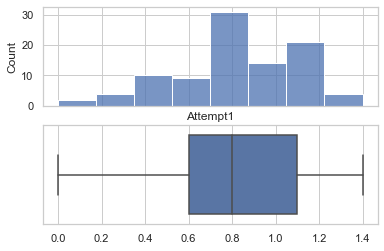

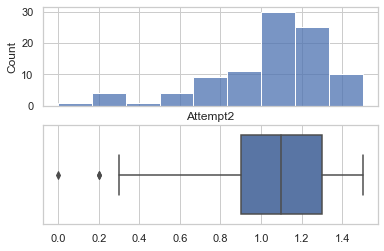

In [5]:
#считываем данные из таблицы
DATA9_3 = pd.read_excel("Data_9_1.xlsx", header = 0)
D9_3 = pd.DataFrame(DATA9_3)
print(D9_3)

#запишем данные из таблицы в массив словарей(ключами каждого словаря(элемента массива) будут фамилия, имя, затр. время и оценка)
D9_3_modified = []
for i in range(0, len(D9_3)):
    elem = {'surname':(D9_3['Фамилия'])[i], 'name':(D9_3['Имя'])[i], 'time_spend':(D9_3['Затраченное время'])[i], 'mark':(D9_3['Оценка/1,50'])[i]}
    D9_3_modified.append(elem)

#теперь сформируем массивы баллов за первую попытку и за вторую попытку
attempt1 = []#в эти два массива будем записывать оценки 
attempt2 = []#из массива словарей D9_3_modified

for i in range(len(D9_3_modified)):
    flag = False#эта переменная отвечает за наличие/отсутствие в D9_3_modified двух элементов с одинаковой фамилией и именем
    elem_number = 0
    
    #для каждого элемента из массива ищем элемент с такой-же фамилией и именем и сохраняем номер в массиве этого элемента в elem_number
    for j in range(i, len(D9_3_modified)):
        if(((D9_3_modified[i])['surname'] == (D9_3_modified[j])['surname']) and ((D9_3_modified[i])['name'] == (D9_3_modified[j])['name']) and (i != j)):
            flag = True
            elem_number = j
            
    #здесь добавляем в массивы attempt1 и attempt2 оценки
    if(flag):
        attempt1.append((D9_3_modified[i])['mark'])
        attempt2.append((D9_3_modified[elem_number])['mark'])
    else:
        attempt1.append((D9_3_modified[i])['mark'])
        attempt2.append('-')#если элемент из D9_3_modified встречался 1 раз, то во вторую попытку добавляем прочерк
        
attempt1_for_convertion = []#так как для дальнейшей работы нам потребуются десятичные числа, то нужно элементы из 
attempt2_for_convertion = []#attempt1 и attempt2 конвертировать во float, поэтому в эти массивы будем записывать конвертированные элементы

Attempt1 = []#а это будут финальные массивы оценок, с которыми мы будем работать
Attempt2 = []

#для того чтобы предостеречь себя от ошибок, проверяем, одной ли длины получились массивы attempt1 и attempt2
if(len(attempt1) == len(attempt2)):
    
    #здесь конвертируем элементы числа во float
    for i in range(len(attempt1)):
        el1 = (attempt1[i]).replace(',', '.')#так как десятичные числа во float представимы с точкой, то заменяем запятую на точку
        attempt1_for_convertion.append(el1)
        if((attempt2[i]) != '-'):
            el2 = (attempt2[i]).replace(',', '.')
            attempt2_for_convertion.append(el2)
        else:
            attempt2_for_convertion.append(attempt2[i])
    
    #проверяем элементы из attempt1_for_convertion и attempt2_for_convertion на то, 
    #чтобы соответструющие элементы не были равны и на отсутствие в attempt2_for_convertion прочерков
    for i in range(len(attempt1_for_convertion)):
        if(attempt2_for_convertion[i] != '-'):
            if(np.round((float(attempt1_for_convertion[i]) - float(attempt2_for_convertion[i])), 2) != 0):
                Attempt1.append(float(attempt1_for_convertion[i]))
                Attempt2.append(float(attempt2_for_convertion[i]))
    print(Attempt1)
    print(Attempt2)
else:
    print('Ошибка в коде')
    
print("\n")    

#построение боксплотов и нахождение числовых характеристик(по примеру лр4)
seaborn.set(style = 'whitegrid')
f1, (ax_hist1, ax_box1) = plt.subplots(2, sharex = True)
seaborn.boxplot(Attempt1, ax = ax_box1, orient = 'h')
seaborn.histplot(Attempt1, ax = ax_hist1)
plt.title("Attempt1")

seaborn.set(style = 'whitegrid')
f2, (ax_hist2, ax_box2) = plt.subplots(2, sharex = True)
seaborn.boxplot(Attempt2, ax = ax_box2, orient = 'h')
seaborn.histplot(Attempt2, ax = ax_hist2)
plt.title("Attempt2")

print("ЧИСЛОВЫЕ ХАРАКТЕРИСТИКИ ВЫБОРКИ Attempt1\n")
m_at1 = np.mean(Attempt1)
d_at1 = np.var(Attempt1, ddof = 0)
mediana_at1 = np.median(Attempt1)
print("Медиана:", m_at1)
print("Дисперсия:", d_at1)
print("СКО:", np.sqrt(d_at1))
print("Медиана:", mediana_at1, "\n")

print("ЧИСЛОВЫЕ ХАРАКТЕРИСТИКИ ВЫБОРКИ Attempt2\n")
m_at2 = np.mean(Attempt2)
d_at2 = np.var(Attempt2, ddof = 0)
mediana_at2 = np.median(Attempt2)
print("Медиана:", m_at2)
print("Дисперсия:", d_at2)
print("СКО:", np.sqrt(d_at2))
print("Медиана:", mediana_at2, "\n")

Теперь проведем анализ сформированных массивов Attempt1 и Attempt2. В качестве основной гипотезы возьмем $H_0: p = \frac{1}{2}$, в качестве альтернативной гипотезы: $H_1: p < \frac{1}{2}$, поскольку нас интересует положительное смещение второй выборки. Воспользуемся статистикой Фишера. Так как альтернативная гипотеза имеет вид $H_1: p < \frac{1}{2}$, то основная гипотеза отклоняется, если выполняется неравенство:
$$F_в = \frac{l-r}{r + 1} \ge F_{1-\alpha}(k_1, k_2)$$ где $k_1 = 2(r + 1)$, $k_2 = 2(l - r)$. Далее, см. комментарии в коде

In [6]:
#задаем массивы знаков, уровней значимости и результатов, а также число положительных разностей
signs = []
alphas = [0.01*i for i in range(1, 101)]
results = []
r = 0


#добавляем в массив знаков -1 есои разность отрицательная и 1 если разность положительная
for i in range(len(Attempt1)):
    if(Attempt1[i] - Attempt2[i] < 0):
        signs.append(-1)
    else:
        signs.append(1)

print('signs', signs)
print('len(signs)', len(signs))
print('amount of -1:', signs.count(-1))
print('amount of 1:', signs.count(1))

l = len(signs)
#считаем число положительных разностей
for i in range(l):
    if(signs[i] == 1):
        r += 1
#считаем k1, k2 и выборочное значение статитстики
k1 = 2*(r + 1)
k2 = 2*(l - r)
F_sel = (l - r)/(r + 1)
for alpha in alphas:
    if(F_sel >= (sts.f(k1, k2)).ppf(1-alpha)):
        results.append("-")
    else:
        results.append("+")
print('results', results)

alphas_plus = []
alphas_minus = []

for i in range(len(results)):
    if(results[i] == "+"):
        alphas_plus.append(alphas[i])
    else:
        alphas_minus.append(alphas[i])


print("Основная гипотеза принимается, утверждение из условия считается неверным при alpha")
print(np.round(alphas_plus, 2))
print("Основная гипотеза отклоняется, утверждение из условия считается верным при alpha")
print(np.round(alphas_minus, 2))

signs [-1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, -1, -1, -1, 1, -1, 1, -1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, -1, 1, 1, -1, 1, -1, -1, -1, -1, -1, 1, 1, -1, -1, -1, 1, 1, -1, -1, 1, -1, 1, -1, 1, -1, 1, -1, -1, -1, -1, 1, -1, -1, -1, -1, -1, -1, 1, -1, -1, -1, -1, -1, -1, -1, -1, 1, -1, -1, -1, -1, 1, -1, -1, -1, 1, -1, -1, -1, -1, 1]
len(signs) 95
amount of -1: 71
amount of 1: 24
results ['-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-']
Основная гипотеза принимается, утверждение из условия считается неверным при alph

Можно сделать вывод, что при любом уровне значимости $\alpha$ можно считать, что опыт выполнения теста улучшил способности учащихся в решении задач.

$\newline$

## Задание 4: Преподаватели Иванов и Петров, сидя за чашкой чая, сетовали на то, что студенты год от года учатся все хуже и хуже… Но так ли это? В файле «Данные 9_2» приведены данные успеваемости студентов, изучавших дисциплину «Основы математического анализа» в 2022 и 2023 году. Проанализируйте статистические данные по следующему плану:  
1)  Визуализируйте выборки (постройте гистограммы и боксплоты), а также найдите выборочные числовые характеристики.   
2)  Проверьте гипотезу об однородности генеральных совокупностей в части равенства характеристик положения, используя критерий Уилкоксона – Манна – Уитни.  

## Решение: 
## Пункт 1: Для начала импортируем данные, построим гистограммы с боксплотами выборок и найдем числовые характеристики выборок.

      ОМА_итог_22   ОМА_итог_23
0           0.581        0.5175
1           0.580        0.9000
2           0.860        0.2670
3           0.650        0.2210
4           0.520        0.5000
..            ...           ...
260         0.865           NaN
261         0.607           NaN
262         0.380           NaN
263           NaN           NaN
264         0.354           NaN

[265 rows x 2 columns]


C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


ЧИСЛОВЫЕ ХАРАКТЕРИСТИКИ ВЫБОРКИ ОМА_22

Медиана: 0.5344223735408561
Дисперсия: 0.028863552836000544
СКО: 0.16989276863951727
Медиана: 0.535 

ЧИСЛОВЫЕ ХАРАКТЕРИСТИКИ ВЫБОРКИ ОМА_23

Медиана: 0.5240823529411766
Дисперсия: 0.03557555008073815
СКО: 0.18861481935611038
Медиана: 0.53


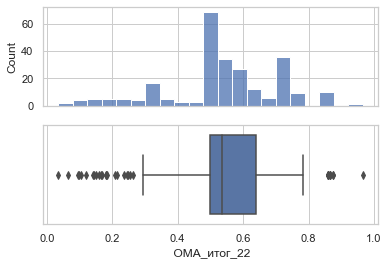

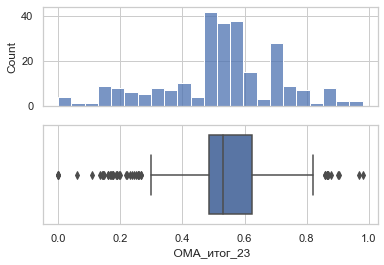

In [7]:
#импортируем данные
DATA9_4 = pd.read_excel("Data_9_2.xlsx", header = 0)
D9_4 = pd.DataFrame(DATA9_4)
D9_4 = D9_4.astype(float)
print(D9_4)
#задаем массивы с оценками за 22 и за 23 года
OMA22 = D9_4[' ОМА_итог_22'].dropna()
OMA23 = D9_4[' ОМА_итог_23'].dropna()

#строим боксплоты и гистограммы
seaborn.set(style = 'whitegrid')
f3, (ax_hist3, ax_box3) = plt.subplots(2, sharex = True)
seaborn.boxplot(OMA22, ax = ax_box3, orient = 'h')
seaborn.histplot(OMA22, ax = ax_hist3)

seaborn.set(style = 'whitegrid')
f4, (ax_hist4, ax_box4) = plt.subplots(2, sharex = True)
seaborn.boxplot(OMA23, ax = ax_box4, orient = 'h')
seaborn.histplot(OMA23, ax = ax_hist4)

#вычисляем числовые характеристики
print("ЧИСЛОВЫЕ ХАРАКТЕРИСТИКИ ВЫБОРКИ ОМА_22\n")
m_oma22 = np.mean(OMA22)
d_oma22 = np.var(OMA22, ddof = 0)
mediana_oma22 = np.median(OMA22)
print("Медиана:", m_oma22)
print("Дисперсия:", d_oma22)
print("СКО:", np.sqrt(d_oma22))
print("Медиана:", mediana_oma22, "\n")

print("ЧИСЛОВЫЕ ХАРАКТЕРИСТИКИ ВЫБОРКИ ОМА_23\n")
m_oma23 = np.mean(OMA23)
d_oma23 = np.var(OMA23, ddof = 0)
mediana_oma23 = np.median(OMA23)
print("Медиана:", m_oma23)
print("Дисперсия:", d_oma23)
print("СКО:", np.sqrt(d_oma23))
print("Медиана:", mediana_oma23)

## Пункт 2: Воспользуемся критерием Уилкоксона – Манна – Уитни. В качестве основной гипотезы $H_0$ возьмем гипотезу, утверждающую о том что выборки OMA22 и OMA23 получены из однородных генеральных совокупностей. В качестве альтернативной гипотезу возьмем правостороннюю альтернативу. Воспользуемся встроенной в питон функцией, sts.mannwhitneyu

In [8]:
Z_SEL, P_VALUE = sts.mannwhitneyu(OMA22, OMA23, use_continuity = True, alternative = "greater")#в поле alternative ставим greater, потому что в качестве альтернативной гипотезы мы взяли правостороннюю альтернативу
print('Z_sel', Z_SEL)
print('P_VALUE', P_VALUE)

Z_sel 33098.0
P_VALUE 0.4218346949070863


ВЫВОД: При $\alpha \gt 0.4218346949070863$ основная гипотеза отклоняется, т.е утверждение из условия считается верным. При $\alpha \le 0.4218346949070863$ основная гипотеза принимается, т.е утверждение из условия считается неверным.